# Análisis predictivo de mutaciones en gliomas cerebrales
### Por Alejandro Benítez Berná

Los gliomas son los tumores más comunes del cerebro y se clasifican en dos grupos según su agresividad: LGG (Glioma de Bajo Grado) y GBM (Glioblastoma Multiforme). Tradicionalmente, la gradación se realiza mediante criterios histológicos e imágenes, pero los factores moleculares y mutacionales son ahora cruciales para un diagnóstico preciso.

Sin embargo, realizar pruebas moleculares exhaustivas es tiene un coste muy alto. El desafío aquí es utilizar datos de 20 genes frecuentemente mutados para predecir correctamente el grado del tumor.

El objetivo es desarrollar un modelo predictivo que determine si un paciente tiene LGG o GBM basándose en su perfil clínico y mutacional, e identificar el subconjunto óptimo de genes y características clínicas que permitan una gradación precisa, buscando mejorar el rendimiento del diagnóstico y reducir los costos asociados a las pruebas moleculares.

## Diccionario de variables

### Variables básicas
* **Grade:** Representa la agresividad del tumor. 
    * 0: LGG (Glioma de Bajo Grado).
    * 1: GBM (Glioblastoma Multiforme).
* **Gender:** Género biológico del paciente.
    * 0: Masculino.
    * 1: Femenino.
* **Age_at_diagnosis**: Edad del paciente al momento del diagnóstico (en años, formato decimal).
* **Race:** Grupo étnico o raza reportada del paciente (codificado numéricamente).

### Variables del estado mutacional de genes (firmas moleculares):
1. **IDH1:** Isocitrato deshidrogenasa 1.
2. **TP53:** Proteína tumoral p53.
3. **ATRX:** Talasemia alfa/retraso mental ligado al cromosoma X.
4. **PTEN:** Homólogo de fosfatasa y tensina.
5. **EGFR:** Receptor del factor de crecimiento epidérmico.
6. **CIC:** Homólogo de capicua.
7. **MUC16:** Mucina 16 (antígeno CA125).
8. **PIK3CA:** Fosfatidilinositol-4,5-bifosfato 3-quinasa alfa.
9. **NF1:** Neurofibromina 1.
10. **PIK3R1:** Fosfatidilinositol 3-quinasa subunidad reguladora 1.
11. **FUBP1:** Proteína de unión al elemento corriente arriba 1.
12. **RB1:** Proteína del retinoblastoma 1.
13. **NOTCH1:** Notch homólogo 1.
14. **BCOR:** Corepresor de BCL6.
15. **CSMD3:** Dominio CUB y Sushi múltiple 3.
16. **SMARCA4:** Subunidad A4 del complejo SWI/SNF.
17. **GRIN2A:** Subunidad 2A del receptor de glutamato NMDA.
18. **IDH2:** Isocitrato deshidrogenasa 2.
19. **FAT4:** Proteína cadherina FAT 4.
20. **PDGFRA:** Receptor alfa del factor de crecimiento derivado de plaquetas.

## Análisis univariante

### Inserción de datos para el análisis

In [27]:
%pip install matplotlib seaborn pandas

import pandas as pd

df_info = pd.read_csv('TCGA_InfoWithGrade.csv')

# Comprobación
print("¡Datos cargados correctamente!")
df_info.head()

Note: you may need to restart the kernel to use updated packages.
¡Datos cargados correctamente!


,Grade,Gender,Age_at_diagnosis,Race,IDH1,TP53,ATRX,PTEN,EGFR,CIC,...,FUBP1,RB1,NOTCH1,BCOR,CSMD3,SMARCA4,GRIN2A,IDH2,FAT4,PDGFRA
0,0,0,51.30,0,1,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
1,0,0,38.72,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,0,0,35.17,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,1,32.78,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,1,0
4,0,0,31.51,0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Frecuencia de grados de glioma
Conteo de cuántos pacientes hay de cada tipo de tumor entre LGG (0) y GBM (1).

/tmp/ipykernel_183469/2455967442.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df_info, x='Grade', palette='viridis')
/tmp/ipykernel_183469/2455967442.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['LGG (Bajo Grado)', 'GBM (Glioblastoma)'])


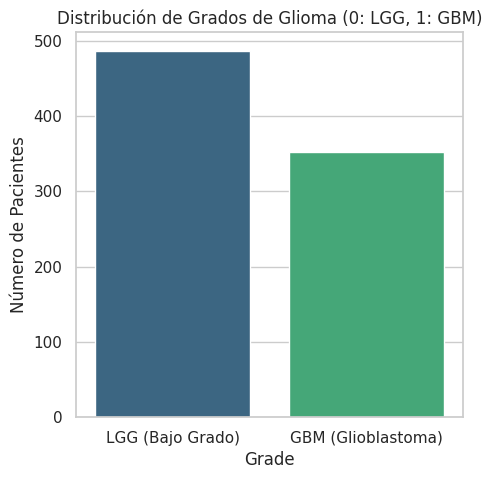

Frecuencia de cada grado:
Grade
0    58.045292
1    41.954708
Name: proportion, dtype: float64


In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")

# 1. Distribución de la variable objetivo (Grade)
plt.figure(figsize=(5, 5))
ax = sns.countplot(data=df_info, x='Grade', palette='viridis')
ax.set_title('Distribución de Grados de Glioma (0: LGG, 1: GBM)')
ax.set_xticklabels(['LGG (Bajo Grado)', 'GBM (Glioblastoma)'])
plt.ylabel('Número de Pacientes')
plt.show()

# Mostrar porcentajes
print("Frecuencia de cada grado:")
print(df_info['Grade'].value_counts(normalize=True) * 100)

### Distribución de la edad
histograma para identificar en qué rango de años se concentran la mayoría de los diagnósticos.

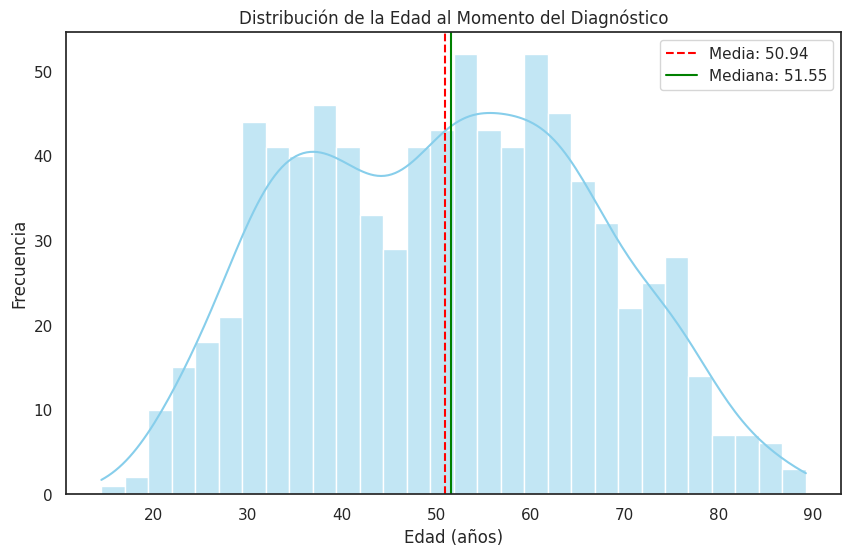

count    839.000000
mean      50.935411
std       15.702339
min       14.420000
25%       38.055000
50%       51.550000
75%       62.800000
max       89.290000
Name: Age_at_diagnosis, dtype: float64


In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="white")

# Histograma de la edad
plt.figure(figsize=(10, 6))
sns.histplot(df_info['Age_at_diagnosis'], kde=True, color="skyblue", bins=30)

# Líneas para la media y la mediana
plt.axvline(df_info['Age_at_diagnosis'].mean(), color='red', linestyle='--', label=f"Media: {df_info['Age_at_diagnosis'].mean():.2f}")
plt.axvline(df_info['Age_at_diagnosis'].median(), color='green', linestyle='-', label=f"Mediana: {df_info['Age_at_diagnosis'].median():.2f}")

plt.title('Distribución de la Edad al Momento del Diagnóstico')
plt.xlabel('Edad (años)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

# Estadísticas descriptivas básicas
print(df_info['Age_at_diagnosis'].describe())

### Perfil de género y raza
Gráficos de barras para entender la composición demográfica de la muestra y detectar posibles sesgos.

/tmp/ipykernel_183469/2279591462.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_info, x='Gender', ax=axes[0], palette='pastel')
/tmp/ipykernel_183469/2279591462.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Masculino (0)', 'Femenino (1)'])
/tmp/ipykernel_183469/2279591462.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_info, x='Race', ax=axes[1], palette='muted')


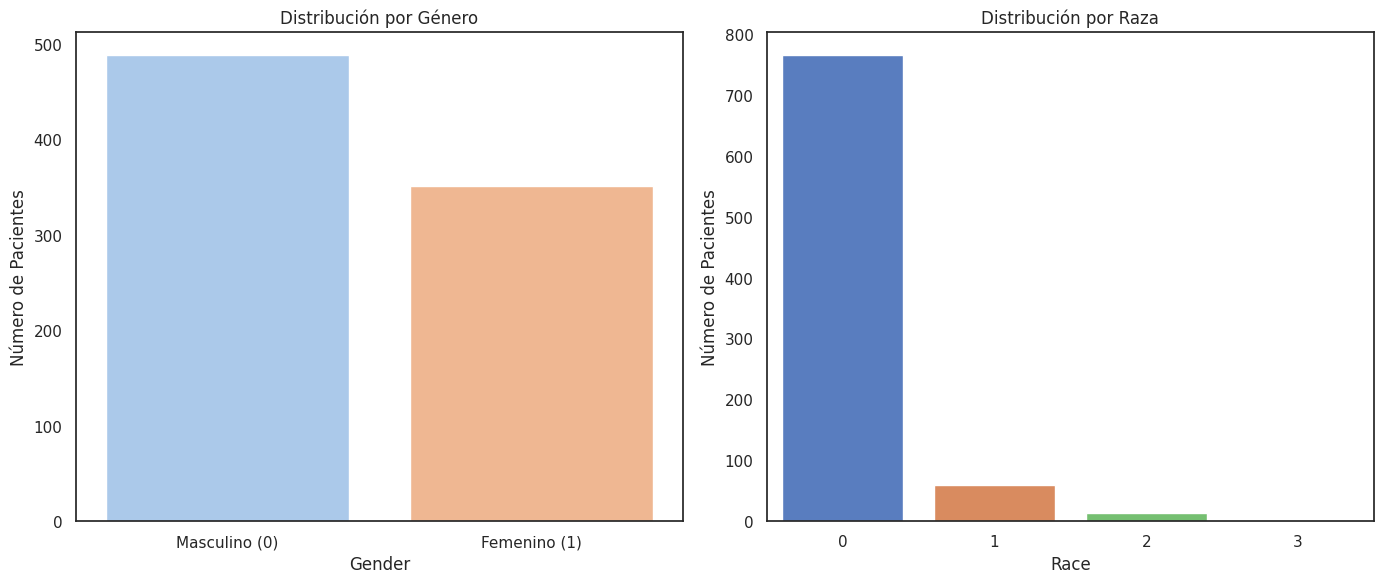

Conteo por Género:
 Gender
0    488
1    351
Name: count, dtype: int64

Conteo por Raza:
 Race
0    765
1     59
2     14
3      1
Name: count, dtype: int64


In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Distribución por Género
sns.countplot(data=df_info, x='Gender', ax=axes[0], palette='pastel')
axes[0].set_title('Distribución por Género')
axes[0].set_xticklabels(['Masculino (0)', 'Femenino (1)'])
axes[0].set_ylabel('Número de Pacientes')

# Distribución por Raza
sns.countplot(data=df_info, x='Race', ax=axes[1], palette='muted')
axes[1].set_title('Distribución por Raza')
axes[1].set_ylabel('Número de Pacientes')

plt.tight_layout()
plt.show()

print("Conteo por Género:\n", df_info['Gender'].value_counts())
print("\nConteo por Raza:\n", df_info['Race'].value_counts())

### Frecuencia de mutaciones
Un ranking de los 20 genes para ver cuáles son los que mutan con más frecuencia en toda la población estudiada.

/tmp/ipykernel_183469/758526432.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mutations_count.values, y=mutations_count.index, palette='magma')


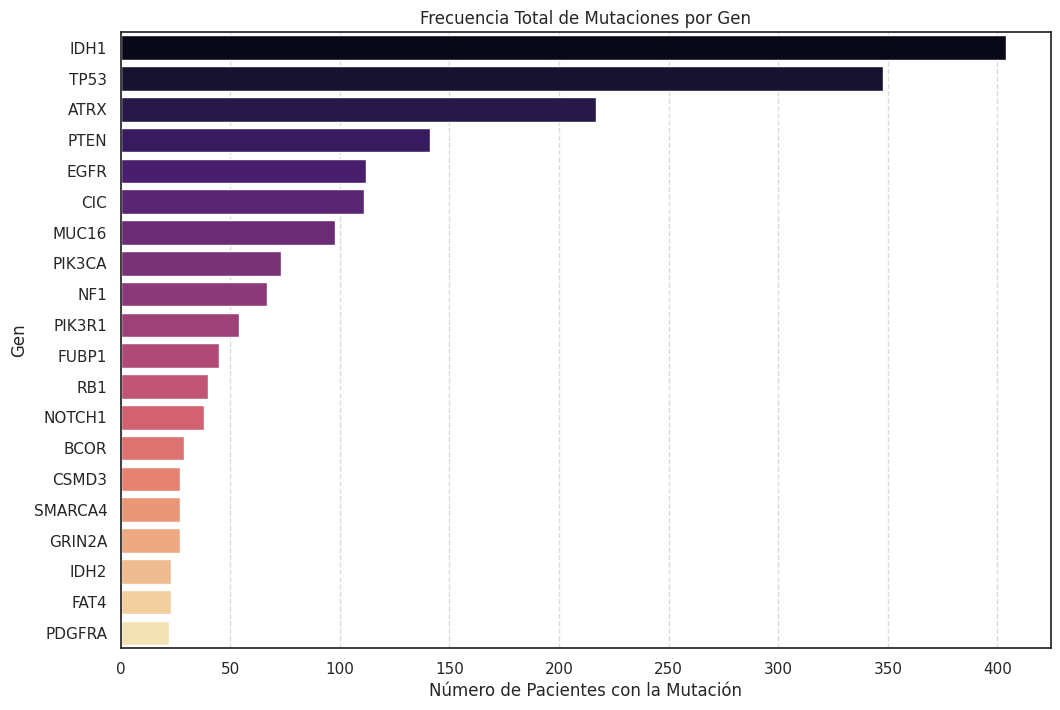

In [31]:
# Genes
genes = ['IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA',
         'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 
         'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']

# Suma de mutaciones 
mutations_count = df_info[genes].sum().sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=mutations_count.values, y=mutations_count.index, palette='magma')

plt.title('Frecuencia Total de Mutaciones por Gen')
plt.xlabel('Número de Pacientes con la Mutación')
plt.ylabel('Gen')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Análisis bivariante/multivariante justificado

### Edad vs Grado del tumor
Comparación mediante diagramas de caja (boxplots) para confirmar si los tumores más agresivos (GBM) suelen aparecer en pacientes de mayor edad.

/tmp/ipykernel_183469/114206178.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_info, x='Grade', y='Age_at_diagnosis', palette='Set2')


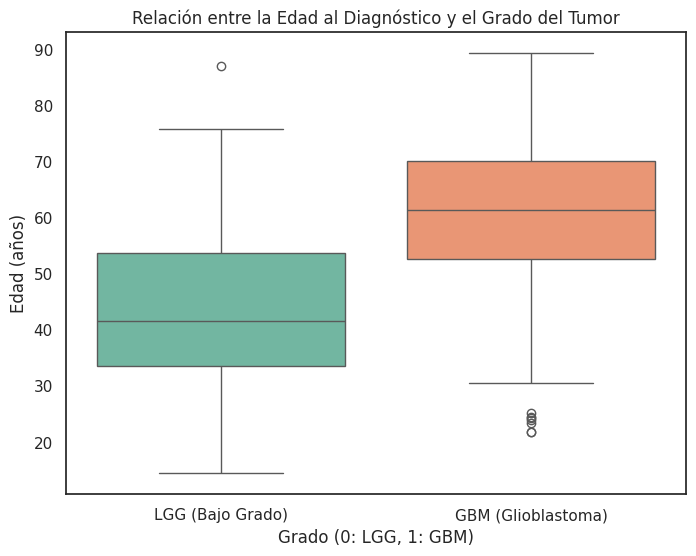

Estadísticas de edad agrupadas por Grado:
       count       mean        std    min     25%     50%     75%    max
Grade                                                                   
0      487.0  43.874928  13.261726  14.42  33.530  41.610  53.745  87.00
1      352.0  60.703750  13.427080  21.73  52.665  61.395  69.995  89.29


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Gráfico de caja
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_info, x='Grade', y='Age_at_diagnosis', palette='Set2')

plt.title('Relación entre la Edad al Diagnóstico y el Grado del Tumor')
plt.xlabel('Grado (0: LGG, 1: GBM)')
plt.ylabel('Edad (años)')
plt.xticks([0, 1], ['LGG (Bajo Grado)', 'GBM (Glioblastoma)'])
plt.show()

# Estadísticas detalladas para la interpretación
print("Estadísticas de edad agrupadas por Grado:")
print(df_info.groupby('Grade')['Age_at_diagnosis'].describe())

### Mutaciones vs Grado
Comparativa de las tasas de mutación por gen según el tipo de tumor, buscando identificar qué genes son "firmas" características de LGG o GBM.

<Figure size 1600x800 with 0 Axes>

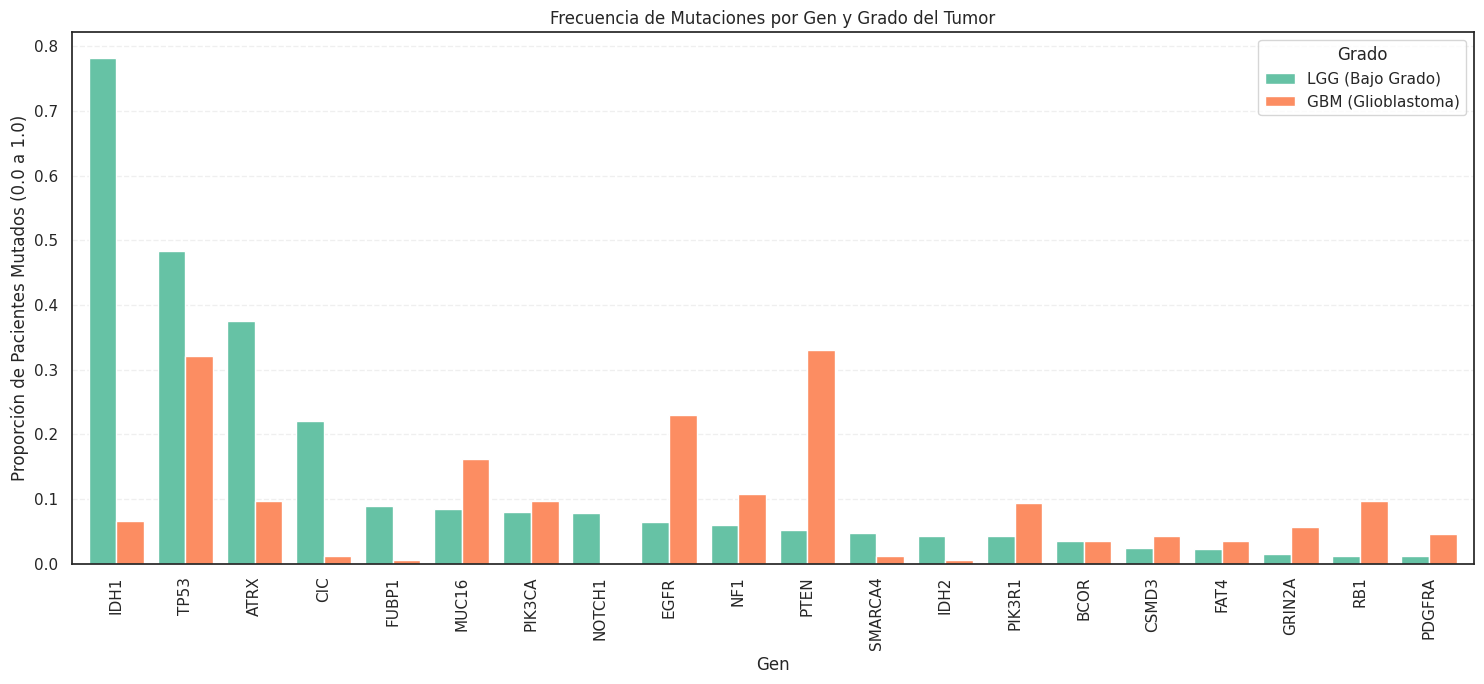

Tasas de mutación por gen (Top 10):
        LGG (Bajo Grado)  GBM (Glioblastoma)
IDH1            0.782341            0.065341
TP53            0.482546            0.321023
ATRX            0.375770            0.096591
CIC             0.219713            0.011364
FUBP1           0.088296            0.005682
MUC16           0.084189            0.161932
PIK3CA          0.080082            0.096591
NOTCH1          0.078029            0.000000
EGFR            0.063655            0.230114
NF1             0.059548            0.107955


In [33]:
genes = ['IDH1', 'TP53', 'ATRX', 'PTEN', 'EGFR', 'CIC', 'MUC16', 'PIK3CA',
         'NF1', 'PIK3R1', 'FUBP1', 'RB1', 'NOTCH1', 'BCOR', 'CSMD3', 
         'SMARCA4', 'GRIN2A', 'IDH2', 'FAT4', 'PDGFRA']

# Tasa de mutación (promedio de 0s y 1s) por cada Grado
# porcentaje de pacientes mutados en cada grupo
mutation_rates = df_info.groupby('Grade')[genes].mean().T
mutation_rates.columns = ['LGG (Bajo Grado)', 'GBM (Glioblastoma)']

# Ordenamos por la frecuencia en LGG para que el gráfico sea más claro
mutation_rates = mutation_rates.sort_values(by='LGG (Bajo Grado)', ascending=False)

plt.figure(figsize=(16, 8))
mutation_rates.plot(kind='bar', figsize=(15, 7), color=['#66c2a5', '#fc8d62'], width=0.8)

plt.title('Frecuencia de Mutaciones por Gen y Grado del Tumor')
plt.xlabel('Gen')
plt.ylabel('Proporción de Pacientes Mutados (0.0 a 1.0)')
plt.legend(title='Grado')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Tabla comparativa de los genes más relevantes
print("Tasas de mutación por gen (Top 10):")
print(mutation_rates.head(10))

## GENERAR HTML

In [34]:
%pip install nbconvert

!jupyter nbconvert --to html glioma.ipynb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21/21 [nbconvert]21 [nbconvert]]up4]
Note: you may need to restart the kernel to use updated packages.
[NbConvertApp] Converting notebook glioma.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 6 image(s).
[NbConvertApp] Writing 653355 bytes to glioma.html
